# La densité et le vote

Par Yasmine Boutchich, Anton Jayet et Fabien Gouy-Waz

## Introduction

La question du lien entre territoires, densité de population et le vote est un sujet récurrent de la sociologie politique. De nombreux auteurs ont ainsi pu opposer grandes agglomérations et milieux ruraux plus isolés comme facteur explicatif du vote. On peut par exemple penser à l'essai controversé de l'essayiste Christophe Guilluy " La France périphérique", où il oppose des métropoles concentrant les vainqueurs de la mondialisation avec une France périphérique des oubliés de la mondialisation et de territoires isolées. Cette division serait à l'origine des divisions entre les votes à gauche et les votes à l'extrême droite. Si cette division a été très critiquée par les géographes pour son simplisme et tous les autres facteurs qu'elle ne prend pas en compte, elle a fortement marqué les débats publics et elle montre l'importance de la question de l'influence des territoires sur le vote

C'est pourquoi il nous a semblé intéressant de croiser les données de population (indiquant les territoires où les électeurs vivent) avec les résultats des dernières élections législatives de 2024. Si les données de population de 2024 ne sont pas encore disponibles, on a quand même fait le choix des élections de 2024 car on part du principe que la population n'évolue pas énormément en seulement quelques années et les dernières élections sont une bonne base de données car il y a eu une forte participation électorale. Dans ce document on étudie donc le lien entre population et le vote. 
    Dans l'autre notebook, nous réalisons le même type d'études, cette fois à partir des données de l'Insee sur le degré de densité, disponibles sur [Degré de densité Insee](https://www.insee.fr/fr/information/8571524). Nous avons trouvé intéressant d'apporter cette nouvelle base de données, car cette classification par degrés de densité était plus précise qu'une simple distinction par le nombre d'habitants. Elle prend en compte en effet la présence de zones de faible surface comprenant un fort nombre d'habitants, et la classification que nous avons retenu prend aussi en compte les aires d'attraction des villes (AAV), pour distinguer les territoires périurbains rattachés à une ville des zones rurales isolées. 

On va donc étudier le lien entre densité et le vote pour voir s'il est un bon facteur explicatif du vote


## Installation

In [114]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import os
import numpy as np

## Préparation des données

On a importé les données des dernières élections législatives depuis l'open data de Data Gouv recensant les données relatives aux élections et référendums de la Vème République. On les a obtenu avec le lien [élections](https://www.data.gouv.fr/pages/donnees-des-elections). On a trouvé également les données de population par communes à partir de data gouv qui renvoie vers les résultats de recensement de l'Insee [population_communes](https://www.data.gouv.fr/datasets/population). 

In [115]:
# Télécharger population si pas déjà présent
if not os.path.exists("data/raw/population_communes.xlsx"):
    from src.fetch_population import download_population
    download_population()

# Télécharger élections si pas déjà présent
if not os.path.exists("data/raw/elections_legislatives.xlsx"):
    from src.fetch_elections import download_elections
    download_elections()

# Télécharger élections 1er tour
if not os.path.exists("data/raw/elections_t1_legislatives.xlsx"):
    from src.fetch_elections_t1 import download_elections
    download_elections()

In [116]:
# Configuration et chargement
FILE_PATH = 'data/raw/elections_t1_legislatives.xlsx'
df_raw = pd.read_excel(FILE_PATH, dtype=str)

### Passage en fichier long

Le document recensant les résultats du 1er tour est originellement en format wide, ce qui pose problème car de nombreuses colonnes étaient vides en l'absence de candidats et cela empêchait de merge avec les données de population et de réaliser des statistiques descriptives. Comme vu en TD et pour un meilleur traitement des données, nous avons donc transformé ce fichier en format long pour éviter d'avoir des colonnes vides et pour avoir un document plus lisible.

In [117]:
# Transformation du fichier wide en un fichier long
print("Pivotage des colonnes candidats...")
pieces = []
# On combine les colonnes fixes de tes deux versions
cols_fixes = ['Code département', 'Libellé département', 'Code commune', 'Libellé commune', 'Inscrits', 'Exprimés']

for i in range(1, 200):
    col_nuance = f'Nuance candidat {i}'
    col_voix = f'Voix {i}'
    
    if col_nuance not in df_raw.columns:
        break
        
    temp = df_raw[cols_fixes + [col_nuance, col_voix]].copy()
    temp.columns = cols_fixes + ['Nuance', 'Voix']
    temp = temp.dropna(subset=['Nuance'])
    pieces.append(temp)

df_long = pd.concat(pieces, ignore_index=True)

Pivotage des colonnes candidats...


### Nettoyage numérique et traitement des valeurs manquantes

Pour éviter que Pandas ne traite les colonnes comme du texte, nous transformons toutes les valeurs des colonnes en valeurs numériques et on remplace les valeurs manquantes par des 0 pour éviter tout problème de calcul dans la réalisation des statistiques descriptives.

In [118]:
# Nettoyage numérique immédiat
df_long['Voix'] = pd.to_numeric(df_long['Voix'], errors='coerce').fillna(0)
df_long['Inscrits'] = pd.to_numeric(df_long['Inscrits'], errors='coerce').fillna(0)
df_long['Exprimés'] = pd.to_numeric(df_long['Exprimés'], errors='coerce').fillna(0)

### Division en blocs politiques

Pour simplifier les graphiques et les analyses, on regroupe en quatre différents blocs politiques les différents partis: la gauche avec les partis du NFP, le centre avec les partis proches de Renaissance, la droite avec les Républicains et l'extrême droite avec le RN, Reconquête et leurs alliés. Nous avons fait ce choix pour deux raisons: d'abord pour que les graphiques et tableaux soient davantage lisibles mais aussi car cela nous semblait plus cohérent d'analyser le vote selon la densité en terme de positionnement politique plutôt que pour chaue parti individuellement avec leurs spécificités. On détecte donc dans ce code toutes les colonnes et on les regroupe dans une seule colonne regroupant chaque nuance d'un des quatre blocs politiques

In [139]:
# Attribution des 4 blocs politiques
print("Attribution des blocs politiques")
def get_bloc(nuance):
    if nuance in ['UG', 'VEC', 'FI', 'SOC', 'COM', 'ECO', 'DVG', 'RDG', 'DXG']: return 'GAUCHE_NFP'
    elif nuance in ['ENS', 'DVC', 'UDI', 'HOR', 'MDM', 'REN']: return 'CENTRE'
    elif nuance in ['LR', 'DVD']: return 'DROITE'
    elif nuance in ['RN', 'UXD', 'REC', 'DSV']: return 'EXTREME_DROITE'
    else: return 'AUTRE'

df_long['BLOC'] = df_long['Nuance'].apply(get_bloc)

Attribution des blocs politiques


## Premiers résultats

### Calcul des pourcentages par communes

Afin de réaliser des statistiques, nous calculons les scores en pourcentage pour chaque bloc séparément. Nous implantons d'abord les blocs politiques dans le fichier long puis on somme les résultats avant de les transformer en pourcentages. Cela permet d'avoir le score de chaque bloc politique dans chaque commune.

In [140]:
# Agrégation et calcul des pourcentages
print("Calcul des scores par commune")
df_communes = df_long.pivot_table(
    index=['Code département', 'Libellé département', 'Code commune', 'Libellé commune', 'Inscrits'],
    columns='BLOC',
    values='Voix',
    aggfunc='sum'
).fillna(0).reset_index()

cols_blocs = ['GAUCHE_NFP', 'CENTRE', 'DROITE', 'EXTREME_DROITE', 'AUTRE']

for col in cols_blocs:
    if col in df_communes.columns:
        # On s'assure que chaque bloc est bien un nombre avant de faire la somme
        df_communes[col] = pd.to_numeric(df_communes[col], errors='coerce').fillna(0)

# Calcul des pourcentages sur le total réel (incluant AUTRE)
cols_blocs = ['GAUCHE_NFP', 'CENTRE', 'DROITE', 'EXTREME_DROITE', 'AUTRE']
df_communes['Total_Voix'] = df_communes[cols_blocs].sum(axis=1)

# On évite la division par zéro
df_communes = df_communes[df_communes['Total_Voix'] > 0].copy()

for bloc in cols_blocs:
    df_communes[f'Pct_{bloc}'] = (df_communes[bloc] / df_communes['Total_Voix']) * 100

Calcul des scores par commune


### Vérification

On constate dans ce tableau que l'on a bien dans chaque commune le nombre de votes et les pourcentages de chaque bloc politique par communes.

In [121]:
print(f"Traitement terminé : {len(df_communes)} communes prêtes.")
display(df_communes.head())

Traitement terminé : 35229 communes prêtes.


BLOC,Code département,Libellé département,Code commune,Libellé commune,Inscrits,AUTRE,CENTRE,DROITE,EXTREME_DROITE,GAUCHE_NFP,Total_Voix,Pct_GAUCHE_NFP,Pct_CENTRE,Pct_DROITE,Pct_EXTREME_DROITE,Pct_AUTRE
0,1,Ain,1001,L'Abergement-Clémenciat,662,2.00,86.00,47.00,258.00,83.00,476.00,17.44,18.07,9.87,54.20,0.42
1,1,Ain,1002,L'Abergement-de-Varey,228,1.00,19.00,45.00,42.00,64.00,171.00,37.43,11.11,26.32,24.56,0.58
2,1,Ain,1004,Ambérieu-en-Bugey,8744,94.00,789.00,989.00,2208.00,1810.00,5890.00,30.73,13.40,16.79,37.49,1.60
3,1,Ain,1005,Ambérieux-en-Dombes,1337,15.00,198.00,61.00,494.00,173.00,941.00,18.38,21.04,6.48,52.50,1.59
4,1,Ain,1006,Ambléon,98,2.00,22.00,3.00,24.00,14.00,65.00,21.54,33.85,4.62,36.92,3.08


### Structure du vote selon la taille de la commune

Nous avons fait le choix de diviser les communes selon quatre tranches de population:

1. On considère comme des communes du rural les communes de moins de 2000 habitants (base de la définition du rural). On pose 1500 comme limite car on part du principe que les inscrits sur les listes électorales représentent environ 75% des habitants d'une commune
2. On suit la même logique en désignant les petites villes comme celles de moins de 20 000 habitants
3. Les villes moyennes jusque 100 000 habitants
4. Les grandes villes à partir de 100 000 habitants et plus

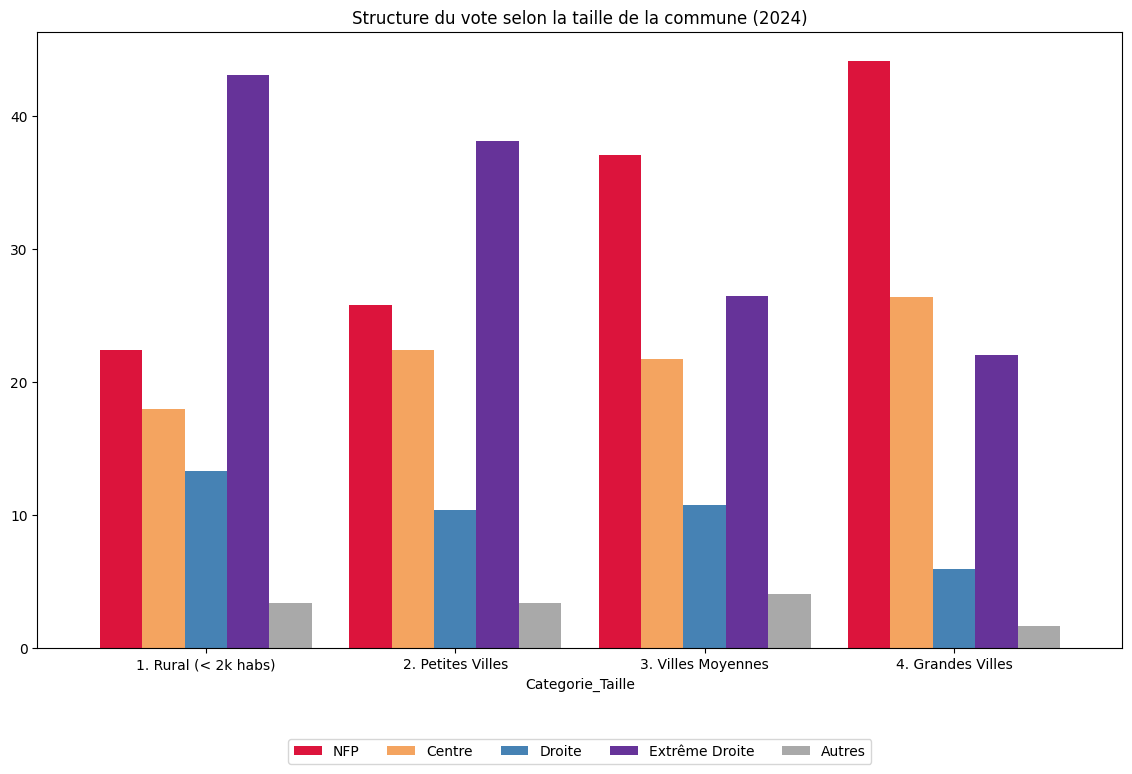

BLOC,Pct_GAUCHE_NFP,Pct_CENTRE,Pct_DROITE,Pct_EXTREME_DROITE,Pct_AUTRE
Categorie_Taille,,,,,
1. Rural (< 2k habs),22.40,17.90,13.30,43.10,3.40
2. Petites Villes,25.80,22.40,10.30,38.10,3.40
3. Villes Moyennes,37.00,21.70,10.80,26.50,4.00
4. Grandes Villes,44.10,26.30,5.90,22.00,1.60


In [122]:
df_communes['Inscrits'] = pd.to_numeric(df_communes['Inscrits'], errors='coerce').fillna(0)

# Tranches de taille
bins = [0, 1500, 15000, 75000, 10000000]
labels = ['1. Rural (< 2k habs)', '2. Petites Villes', '3. Villes Moyennes', '4. Grandes Villes']
df_communes['Categorie_Taille'] = pd.cut(df_communes['Inscrits'], bins=bins, labels=labels)

# Moyennes par catégorie
cols_to_plot = ['Pct_GAUCHE_NFP', 'Pct_CENTRE', 'Pct_DROITE', 'Pct_EXTREME_DROITE', 'Pct_AUTRE']
df_graph = df_communes.groupby('Categorie_Taille', observed=False)[cols_to_plot].mean()

# Affichage du graphique
ax = df_graph.plot(kind='bar', figsize=(14, 8), width=0.85, rot=0, 
                   color=['crimson', 'sandybrown', 'steelblue', 'rebeccapurple', 'darkgray'])

plt.title("Structure du vote selon la taille de la commune (2024)")
plt.legend(["NFP", "Centre", "Droite", "Extrême Droite", "Autres"], loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=5)
plt.show()

display(df_graph.round(1))

On constate comme attendu une hausse des votes pour la gauche avec le nombre d'habitants et l'effet inverse avec l'extrême droite: si le pourcentage de voix pour la gauche double entre le rural et les grandes villes, le vote pour l'extrême droite est lui divisé par deux. On voit déjà avec ces statistiques qu'il semble bien exister un lien entre densité et vote.

### Préparation de la fusion des bases

Dans la base de données des élections, le code des communes est à 4 chiffres. Or c'est une colonne en commun avec la base de données des populations et nous mettons donc le 0 manquant en premier terme dans la base des élections pour rendre les valeurs de ces colonnes communes avec "code_commune". Cela nous permettra ensuite de fusionner les deux tables. 

In [124]:
# Création de la colonne code_commune à 5 chiffres pour le futur merge
df_communes2 = df_communes.copy()
df_communes2['code_commune'] = df_communes2['Code commune'].astype(str).str.zfill(5)
print(f"   Exemple de code généré (Election) : {df_communes2['code_commune'].iloc[0]}")
df_communes2 = df_communes2.drop('Code commune', axis=1)

   Exemple de code généré (Election) : 01001


### Visualisation de la carte électorale

Pour pouvoir représenter la répartition des blocs majoritaires sur la carte de la France, nous regardons quel bloc est gagnant pour chaque commune.

In [123]:
# Création d'une colonne "gagnant" pour la création de la carte
blocs = ['GAUCHE_NFP', 'CENTRE', 'DROITE', 'EXTREME_DROITE']
df_communes['Gagnant'] = df_communes[blocs].idxmax(axis=1)
display(df_communes[['Libellé commune', 'Gagnant']].head())

BLOC,Libellé commune,Gagnant
0,L'Abergement-Clémenciat,EXTREME_DROITE
1,L'Abergement-de-Varey,GAUCHE_NFP
2,Ambérieu-en-Bugey,EXTREME_DROITE
3,Ambérieux-en-Dombes,EXTREME_DROITE
4,Ambléon,EXTREME_DROITE


A l'aide du lien ci-dessous de l'insee avec les coordonnées GPS, on peut représenter sur la carte les gagnants du premier tour de l'élection législatives. Nous avons pu fusionner les données grâce à la colonne "code_commune". 

4. Téléchargement GPS...
   Exemple de code téléchargé (GPS) : 85136
5. Tentative de fusion...
--> SUCCÈS : 34925 communes placées sur la carte !


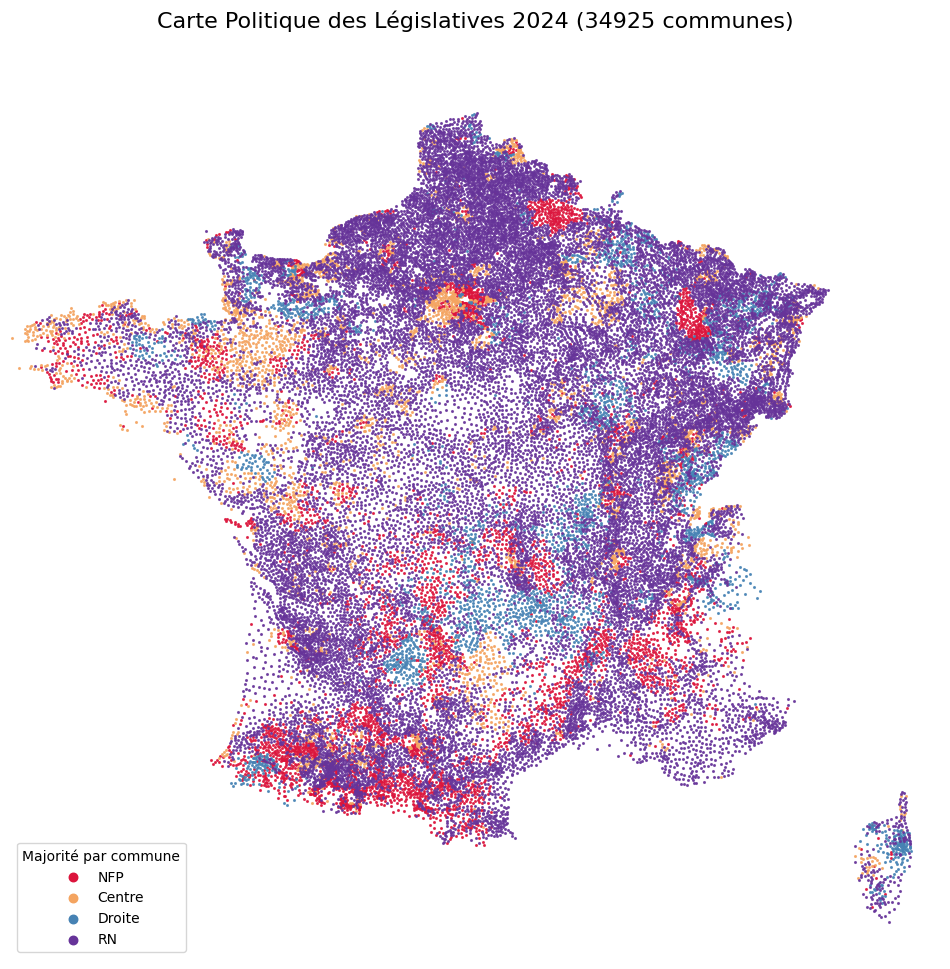

L'image 'carte_electorale_france_2024.png' a été sauvegardée.


In [125]:
# Données GPS
print("4. Téléchargement GPS...")
url_geo = "https://public.opendatasoft.com/explore/dataset/correspondance-code-insee-code-postal/download/?format=csv&use_labels_for_header=true"

try:
    # On télécharge les données de correspondance INSEE/GPS
    df_geo = pd.read_csv(url_geo, sep=';', dtype=str)
except Exception as e:
    print(f"Erreur téléchargement GPS : {e}")
    # Arrêt du script en cas d'erreur de téléchargement
    raise

# Identification automatique des colonnes de codes et de points géo
col_code_geo = next((c for c in ['Code INSEE', 'insee_com'] if c in df_geo.columns), None)
col_geo_point = next((c for c in ['Geo Point', 'geo_point_2d'] if c in df_geo.columns), None)

# Nettoyage et extraction des coordonnées Latitude / Longitude
gps = df_geo[col_geo_point].str.split(',', expand=True)
df_geo['Lat'] = pd.to_numeric(gps[0], errors='coerce')
df_geo['Lon'] = pd.to_numeric(gps[1], errors='coerce')

print(f"   Exemple de code téléchargé (GPS) : {df_geo[col_code_geo].iloc[0]}")

# Merge par code_commune 
print("5. Tentative de fusion...")
df_carte = pd.merge(df_communes2, df_geo, left_on='code_commune', right_on=col_code_geo, how='inner')

# Si la fusion par code échoue
if len(df_carte) < 1000:
    print(f"   Échec fusion par codes ({len(df_carte)} villes). Passage au PLAN B (Par Nom)...")
    
    # Création d'une clé par NOM + Département pour plus de sécurité
    df_communes2['KEY_NOM'] = df_communes2['Nom_commune'].str.upper() + "_" + df_communes2['Code_dep_clean']
    
    col_nom_geo = next((c for c in ['Nom_commune', 'Nom Officiel Commune', 'Commune', 'Ville'] if c in df_geo.columns), None)
    df_geo['KEY_NOM'] = df_geo[col_nom_geo].str.upper() + "_" + df_geo[col_code_geo].str.slice(0, 2)
    
    df_carte = pd.merge(df_communes2, df_geo, on='KEY_NOM', how='inner')

print(f"--> SUCCÈS : {len(df_carte)} communes placées sur la carte !")

# Dessin de la carte
if len(df_carte) > 0:
    plt.figure(figsize=(12, 12))
    couleurs = {
        'GAUCHE_NFP': 'crimson', 
        'CENTRE': 'sandybrown', 
        'DROITE': 'steelblue', 
        'EXTREME_DROITE': 'rebeccapurple'
    }
    lbls = {"GAUCHE_NFP": "NFP", "CENTRE": "Centre", "DROITE": "Droite", "EXTREME_DROITE": "RN"}

    # Paramétrage de la zone
    plt.xlim(-5, 10)
    plt.ylim(41, 52)

    # On trace les points bloc par bloc pour la légende
    for bloc, color in couleurs.items():
        subset = df_carte[df_carte['Gagnant'] == bloc]
        plt.scatter(subset['Lon'], subset['Lat'], c=color, s=1.5, alpha=0.8, label=lbls[bloc])

    # Configuration de la légende
    leg = plt.legend(markerscale=5, loc='lower left', title="Majorité par commune")
    try:
        handles = getattr(leg, 'legendHandles', None) or getattr(leg, 'legend_handles', None)
        if handles: [lh.set_alpha(1) for lh in handles]
    except:
        pass

    plt.title(f"Carte Politique des Législatives 2024 ({len(df_carte)} communes)", fontsize=16)
    plt.axis('off')
    
    # Sauvegarde
    plt.savefig("carte_electorale_france_2024.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("L'image 'carte_electorale_france_2024.png' a été sauvegardée.")
else:
    print("ERREUR FATALE : Aucune commune n'a pu être localisée. Vérifie les codes INSEE.")

On retrouve sur la carte ce que nous avions déjà aperçu dans le tableau: dans les grandes villes comme Paris, le bleu de l'extrême droite est absent et laisse place au centre et à la gauche. On observe aussi au Sud Ouest une forte présence de la gauche. sur le reste du territoire et des territoires ruraux, on observe une large prédominance du vote RN.

## Le lien entre nombre d'habitants et le vote RN

Nous faisons le choix dans la suite d'étudier plus précisément la problématique du lien entre la densité et le vote à l'extrême droite: nous allons en effet mettre en évidence un lien négatif entre le nombre d'habitants dans une commune et le vote à l'extrême droite.

### Nettoyage de la base pour retenir seulement le vote d'extrême droite

Ce code extrait, nettoie et agrège les résultats de l'extrême droite à l'échelle de chaque commune. Nous effectuons de nouveau la transition vers un format long, nous retenons seulement les données du vote à l'extrême droite et nous les filtrons pour pouvoir étudier l'effet du nombre d'habitants sur ce vote.

In [141]:
from scipy.stats import pearsonr
df = pd.read_excel(FILE_PATH,dtype=str)

# On crée un dictionnaire pour renommer les colonnes mal écrites
col_dep = [c for c in df.columns if 'partement' in c and 'Code' in c][0]
col_libelle = [c for c in df.columns if 'ibell' in c and 'commune' in c][0]
col_inscrits = [c for c in df.columns if 'nscrits' in c][0]

# On renomme proprement
df = df.rename(columns={
    col_dep: 'Code_dep',
    'Code commune': 'Code_commune',
    col_libelle: 'Nom_commune',
    col_inscrits: 'Inscrits'
})

cols_fixes = ['Code_dep', 'Code_commune', 'Nom_commune', 'Inscrits']

# On parcourt les colonnes pour trouver les voix du RN
for i in range(1, 40):
    # On gère les noms de colonnes dynamiques (Voix 1, Voix 2...)
    col_nuance = [c for c in df.columns if f'Nuance candidat {i}' in c]
    col_voix = [c for c in df.columns if f'Voix {i}' in c]
    
    if not col_nuance or not col_voix: break
    
    # On extrait les données de ce candidat
    temp = df[cols_fixes + [col_nuance[0], col_voix[0]]].copy()
    temp.columns = cols_fixes + ['Nuance', 'Voix']
    
    # On convertit les voix en nombres
    temp['Voix'] = pd.to_numeric(temp['Voix'], errors='coerce').fillna(0)
    
    # On ne garde que les candidats d'Extrême Droite
    temp = temp[temp['Nuance'].isin(['RN', 'UXD', 'REC', 'DSV'])] 
    pieces.append(temp)

# On assemble tout
df_rn = pd.concat(pieces, ignore_index=True)

# On additionne les voix par ville
df_analyse = df_rn.pivot_table(index=cols_fixes, values='Voix', aggfunc='sum').reset_index()

# Calcul du pourcentage
df_analyse['Inscrits'] = pd.to_numeric(df_analyse['Inscrits'], errors='coerce')
df_analyse['Pct_RN'] = (df_analyse['Voix'] / df_analyse['Inscrits']) * 100

# Filtre pour enlever les données aberrantes (villes sans inscrits ou DOM-TOM lointains qui écrasent le graph)
df_analyse = df_analyse[(df_analyse['Inscrits'] > 50) & (df_analyse['Inscrits'] < 200000)]

Nettoyage des noms de colonnes...


### Mise en évidence de la corrélation négative entre nombre d'habitants et vote à l'extrême droite

Nous utilisons ces données filtrées pour mettre en évidence avec un nuage de points et une droite de corrélation le lien entre nombre d'habitants et vote RN. Nous nous plaçons sur une échelle logarithmique pour neutraliser par exemple la différence entre Paris et les autres villes et éviter qu'elle ne prenne trop de place dans le calcul de la corrélation.

Génération du graphique...


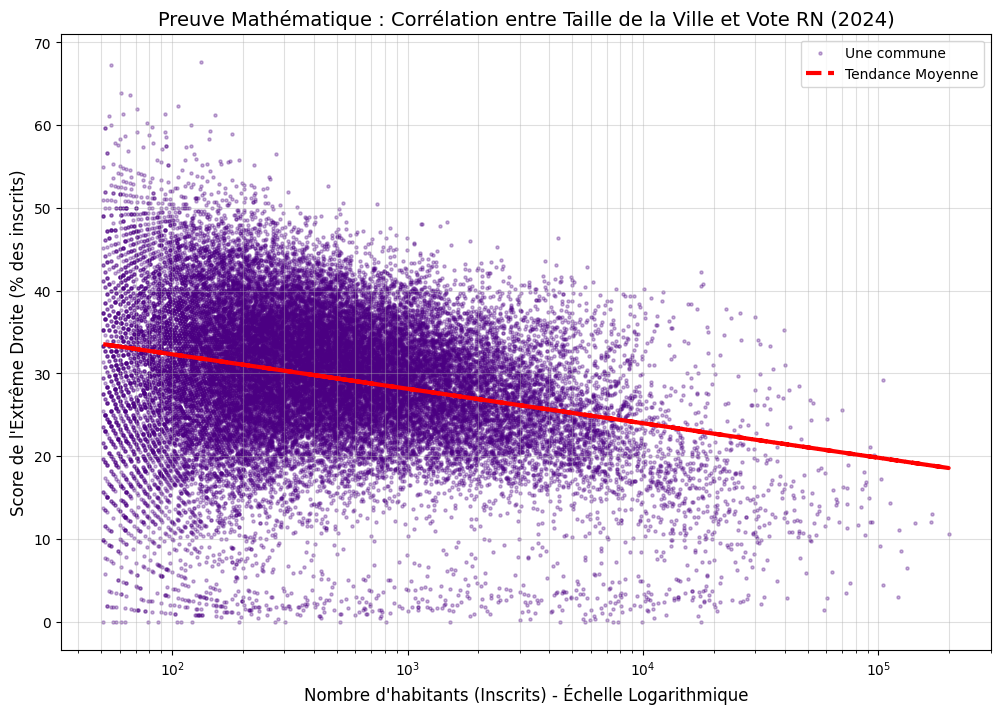

In [143]:
# Le nuage de points
print("Génération du graphique...")
plt.figure(figsize=(12, 8))

# Le Scatter Plot (Nuage)
# x = Taille de la ville (Logarithmique car les écarts sont énormes entre village et Paris)
# y = Score RN
x = df_analyse['Inscrits']
y = df_analyse['Pct_RN']

plt.scatter(x, y, alpha=0.3, s=5, c='indigo', label='Une commune')
plt.xscale('log') # Echelle logarithmique essentielle pour voir quelque chose

# La courbe de tendance
# Elle montre la direction générale du nuage
z = np.polyfit(np.log(x), y, 1)
p = np.poly1d(z)
plt.plot(x, p(np.log(x)), "r--", linewidth=3, label='Tendance Moyenne')

# Esthétique
plt.title("Preuve Mathématique : Corrélation entre Taille de la Ville et Vote RN (2024)", fontsize=14)
plt.xlabel("Nombre d'habitants (Inscrits) - Échelle Logarithmique", fontsize=12)
plt.ylabel("Score de l'Extrême Droite (% des inscrits)", fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.4)

plt.show()

In [134]:
# Calcul de la corrélation de Pearson
corr, _ = pearsonr(np.log(x), y)
print(f"\n>>> RÉSULTAT SCIENTIFIQUE : Le coefficient de corrélation est de {corr:.2f}")
if corr < -0.3:
    print(">>> INTERPRÉTATION : C'est une corrélation NÉGATIVE significative.")
    print("    Cela prouve mathématiquement que plus la population augmente, plus le vote RN baisse.")


>>> RÉSULTAT SCIENTIFIQUE : Le coefficient de corrélation est de -0.27


La courbe de tendance est décroissante et le coefficient de corrélation est de -0,27: on constate donc une corrélation négative, où plus le nombre d'habitants est élevé, moins il y a de votes pour l'extrême droite.

### Le lien entre nombre d'habitants et abstention

Une autre analyse possible à partir des données de la population nous semblait aussi être l'étude de l'abstention en fonction du nombre d'habitants. Cela permettait de dégager encore un autre lien entre nombre d'habitants et vote, autre que le choix d'un parti politique. L'abstention étant aujourd'hui très présente dans chacune des élections, il nous a semblé alors pertinent de mettre en évidence une possible corrélation entre les deux.

Génération du graphique...


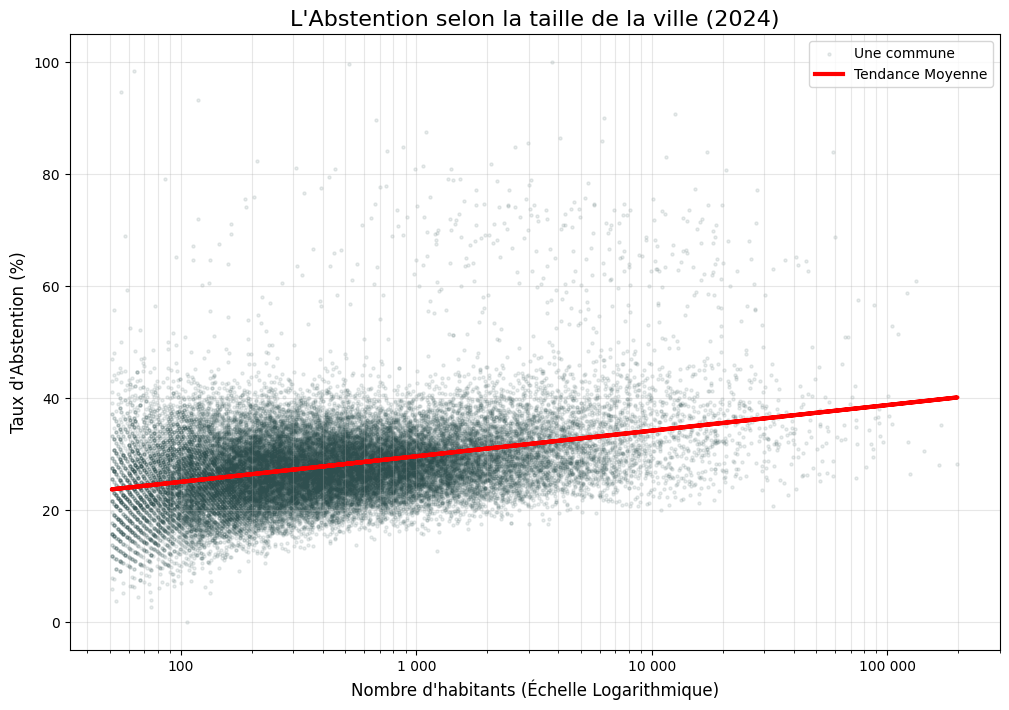

In [145]:
# Identification automatique des colonnes
df = pd.read_excel(FILE_PATH,dtype=str)
try:
    col_inscrits = [c for c in df.columns if 'nscrits' in c and '%' not in c][0]   # "Inscrits"
    col_abst = [c for c in df.columns if 'bstention' in c and '%' not in c][0]     # "Abstentions"
    col_nom = [c for c in df.columns if 'ibell' in c and 'commune' in c][0]        # "Libellé commune"
except IndexError:
    print("Erreur : Colonnes introuvables. Vérifiez votre fichier.")
    # On arrête le script proprement ici si ça plante
    raise SystemExit 

# Extraction des données utiles
df_analyse = df[[col_nom, col_inscrits, col_abst]].copy()
df_analyse.columns = ['Nom', 'Inscrits', 'Abstentions']

# Conversion en nombres
df_analyse['Inscrits'] = pd.to_numeric(df_analyse['Inscrits'], errors='coerce')
df_analyse['Abstentions'] = pd.to_numeric(df_analyse['Abstentions'], errors='coerce')

# Calcul du Taux d'Abstention
df_analyse['Taux_Abstention'] = (df_analyse['Abstentions'] / df_analyse['Inscrits']) * 100

# Filtre pour avoir un graphique propre (on enlève les hameaux de < 50 habitants et les erreurs)
df_clean = df_analyse[(df_analyse['Inscrits'] > 50) & (df_analyse['Inscrits'] < 200000)].dropna()

# Le nuage de points
print("Génération du graphique...")
plt.figure(figsize=(12, 8))

x = df_clean['Inscrits']
y = df_clean['Taux_Abstention']

# Le Nuage
# alpha=0.1 permet de voir où les points s'accumulent (densité)
plt.scatter(x, y, alpha=0.1, s=5, c='darkslategrey', label='Une commune')

# Echelle Logarithmique
plt.xscale('log')

# La Courbe de Tendance
# Elle montre la moyenne glissante
z = np.polyfit(np.log(x), y, 1)
p = np.poly1d(z)
plt.plot(x, p(np.log(x)), "r-", linewidth=3, label='Tendance Moyenne')

# Esthétique
plt.title("L'Abstention selon la taille de la ville (2024)", fontsize=16)
plt.xlabel("Nombre d'habitants (Échelle Logarithmique)", fontsize=12)
plt.ylabel("Taux d'Abstention (%)", fontsize=12)
plt.xticks([100, 1000, 10000, 100000], ['100', '1 000', '10 000', '100 000']) # Etiquettes claires
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()

plt.show()

In [150]:
# Analyse statistique
corr, _ = pearsonr(np.log(x), y)
moyenne_villages = df_clean[df_clean['Inscrits'] < 1000]['Taux_Abstention'].mean()
moyenne_villes = df_clean[df_clean['Inscrits'] > 10000]['Taux_Abstention'].mean()

print(f"\n>>> RÉSULTATS CLÉS :")
print(f"1. Corrélation : {corr:.3f}")
print(f"2. Moyenne Abstention (Villages < 1k habs) : {moyenne_villages:.1f}%")
print(f"3. Moyenne Abstention (Villes > 10k habs)  : {moyenne_villes:.1f}%")


>>> RÉSULTATS CLÉS :
1. Corrélation : 0.355
2. Moyenne Abstention (Villages < 1k habs) : 26.9%
3. Moyenne Abstention (Villes > 10k habs)  : 38.0%


Cette fois on constate que la corrélation est positive: on vote en proportion davantage dans les villages que dans les grandes villes.

### Une dernière représentation

On met en évidence cette fois l'intensité du vote RN selon le type de commune, entre les zones rurales et les grandes villes. De nouveau nous constatons que le vote pour l'extrême droite augmente à chaque fois que nous allons dans une catégorie de villes avec moins d'habitants

1. Chargement et Nettoyage...
2. Création de nouvelles variables...
   -> Impossible de calculer la distance (Erreur GPS: Usecols do not match columns, columns expected but not found: ['Geo Point'])


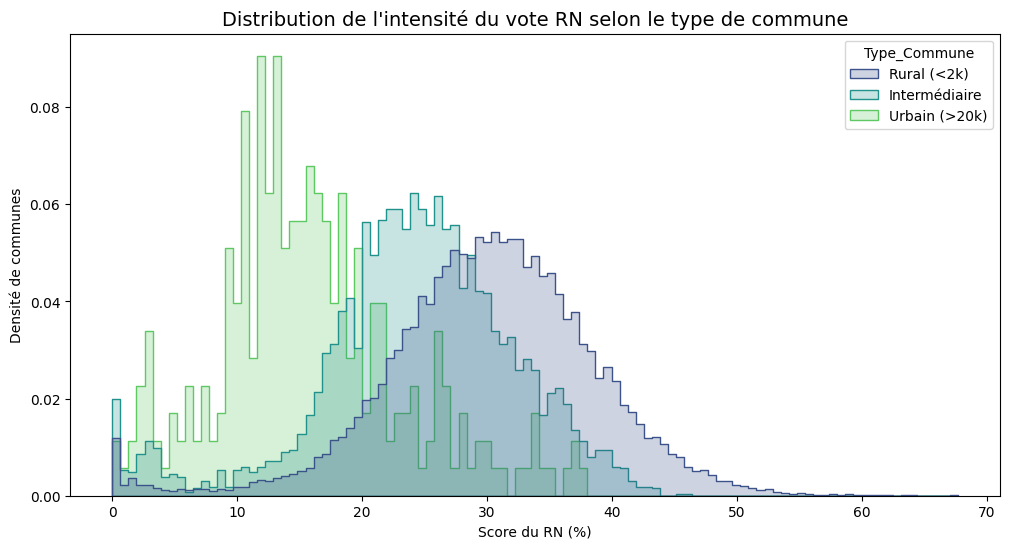

In [148]:
import seaborn as sns

# Chargement et préparation
print("1. Chargement et Nettoyage...")
FILE_PATH = 'data/raw/elections_t1_legislatives.xlsx'
df = pd.read_excel(FILE_PATH,dtype=str)
# Identification des colonnes
col_inscrits = [c for c in df.columns if 'nscrits' in c and '%' not in c][0]
col_blancs = [c for c in df.columns if 'lancs' in c and '%' not in c][0]
col_abst = [c for c in df.columns if 'bstention' in c and '%' not in c][0]
col_code = 'Code commune'
col_dep = [c for c in df.columns if 'partement' in c and 'Code' in c][0]

# Récupération du score RN
pieces = []
for i in range(1, 40):
    col_nuance = [c for c in df.columns if f'Nuance candidat {i}' in c]
    col_voix = [c for c in df.columns if f'Voix {i}' in c]
    if not col_nuance or not col_voix: break
    
    temp = df[[col_dep, col_code, col_nuance[0], col_voix[0]]].copy()
    temp.columns = ['Code_dep', 'Code_commune', 'Nuance', 'Voix']
    temp['Voix'] = pd.to_numeric(temp['Voix'], errors='coerce').fillna(0)
    temp = temp[temp['Nuance'].isin(['RN', 'UXD', 'REC', 'DSV'])] # Bloc Extreme Droite
    pieces.append(temp)

df_rn = pd.concat(pieces, ignore_index=True)
df_rn_sum = df_rn.groupby(['Code_dep', 'Code_commune'])['Voix'].sum().reset_index()

# Création du dataset
df_base = df[[col_dep, col_code, col_inscrits, col_abst, col_blancs]].copy()
df_base.columns = ['Code_dep', 'Code_commune', 'Inscrits', 'Abstentions', 'Blancs']

# Conversion numérique
for c in ['Inscrits', 'Abstentions', 'Blancs']:
    df_base[c] = pd.to_numeric(df_base[c], errors='coerce')

# Fusion avec les voix RN
df_final = pd.merge(df_base, df_rn_sum, on=['Code_dep', 'Code_commune'], how='left').fillna(0)

# Création des nouvelles variables
print("2. Création de nouvelles variables...")

# Pourcentages
df_final['Pct_RN'] = (df_final['Voix'] / df_final['Inscrits']) * 100
df_final['Taux_Abstention'] = (df_final['Abstentions'] / df_final['Inscrits']) * 100
df_final['Taux_Blancs'] = (df_final['Blancs'] / df_final['Inscrits']) * 100

# Catégorie Rural/Urbain
df_final['Type_Commune'] = pd.cut(df_final['Inscrits'], 
                                  bins=[0, 2000, 20000, 10000000], 
                                  labels=['Rural (<2k)', 'Intermédiaire', 'Urbain (>20k)'])

# Variable Distance à Paris
url_geo = "https://public.opendatasoft.com/explore/dataset/correspondance-code-insee-code-postal/download/?format=csv&use_labels_for_header=true"
try:
    df_geo = pd.read_csv(url_geo, sep=';', dtype=str, usecols=['Code INSEE', 'Geo Point'])
    # Nettoyage GPS
    gps = df_geo['Geo Point'].str.split(',', expand=True)
    df_geo['Lat'] = pd.to_numeric(gps[0])
    df_geo['Lon'] = pd.to_numeric(gps[1])
    
    # Création Clé de jointure
    df_final['Key'] = df_final['Code_dep'].str.zfill(2) + df_final['Code_commune'].str.zfill(3)
    
    # Fusion
    df_final = pd.merge(df_final, df_geo, left_on='Key', right_on='Code INSEE', how='inner')
    
    # Calcul de la densité (Formule de Haversine simplifiée pour Paris)
    # Paris : 48.8566, 2.3522
    def dist_paris(row):
        # Approximation rapide (degrés -> km)
        lat_diff = (row['Lat'] - 48.8566) * 111
        lon_diff = (row['Lon'] - 2.3522) * 111 * np.cos(np.radians(48.85))
        return np.sqrt(lat_diff**2 + lon_diff**2)
    
    df_final['Dist_Paris_km'] = df_final.apply(dist_paris, axis=1)
    print("   -> Variable 'Distance à Paris' ajoutée avec succès.")

except Exception as e:
    print(f"   -> Impossible de calculer la distance (Erreur GPS: {e})")
    df_final['Dist_Paris_km'] = np.nan

# Filtre nettoyage
df_final = df_final[(df_final['Inscrits'] > 50) & (df_final['Inscrits'] < 200000)]

# Histogramme comparé du rural et de l'urbain
plt.figure(figsize=(12, 6))
sns.histplot(data=df_final, x='Pct_RN', hue='Type_Commune', element="step", stat="density", common_norm=False, palette='viridis')
plt.title("Distribution de l'intensité du vote RN selon le type de commune", fontsize=14)
plt.xlabel("Score du RN (%)")
plt.ylabel("Densité de communes")
plt.show()

## Le lien entre degré de densité et le vote

Dans cette dernière partie nous utilisons la classification des villes entre quatre différents degrés de densité:
1. Le rural non périurbain
2. Le rural périurbain
3. L'urbain intermédiaire
4. L'urbain dense

Cette subdivision est celle utilisée par l'Insee pour croiser le nombre d'habitants avec l'aire d'attraction des villes. Si c'est proche de notre classification des villes en fonction du nombre d'habitants, cela permet aussi de capter les effets spécifiques de la situation des villages par rapport aux zones d'attractivité économique, sociale... sur le vote de leurs habitants

### Préparation des données

Nous enregistrons d'abord les données de l'Insee dans le dataframe "df_densite". 

In [151]:
#charger degré de densité de population en 2022
df_densite = pd.read_excel("data/raw/Degre_densite.xlsx", skiprows = 4)

#Aperçu des données
print("Degré de densité:")
display(df_densite.head())

Degré de densité:


,CODGEO,LIBGEO,DENS,LIBDENS,PMUN22,P1,P2,P3,DENS_AAV,LIBDENS_AAV,DENS7,LIBDENS7
0,01001,L'Abergement-Clémenciat,3,Rural,859,0.00,0.00,100.00,4,Rural non périurbain,6,Rural à habitat dispersé
1,01002,L'Abergement-de-Varey,3,Rural,273,0.00,0.00,100.00,4,Rural non périurbain,6,Rural à habitat dispersé
2,01004,Ambérieu-en-Bugey,2,Urbain intermédiaire,15554,0.00,96.93,3.07,2,Urbain intermédiaire,2,Centres urbains intermédiaires
3,01005,Ambérieux-en-Dombes,3,Rural,1917,0.00,0.00,100.00,3,Rural périurbain,5,Bourgs ruraux
4,01006,Ambléon,3,Rural,114,0.00,0.00,100.00,4,Rural non périurbain,6,Rural à habitat dispersé


In [155]:
#enregistrement de la nouvelle base de densité dans le dossier processed
# Définition du chemin de destination
target_path = "data/processed/df_densite_clean.xlsx"

# Vérification/Création du dossier de destination
os.makedirs(os.path.dirname(target_path), exist_ok=True)

# Enregistrement en format Excel
df_densite_clean.to_excel(target_path, index=False, sheet_name='Densite_Nettoyee')

print(f"Fichier sauvegardé dans : {target_path}")

Fichier sauvegardé dans : data/processed/df_densite_clean.xlsx


### Sélection des colonnes

Plusieurs colonnes étant inutiles pour l'analyse future des données, nous avons gardé seulement le code_commune pour merge ensuite et la classification des communes selon le degré de densité pour les futures statistiques.

In [156]:
print(df_densite.columns)

Index(['CODGEO', 'LIBGEO', 'DENS', 'LIBDENS', 'PMUN22', 'P1', 'P2', 'P3',
       'DENS_AAV', 'LIBDENS_AAV', 'DENS7', 'LIBDENS7'],
      dtype='object')


In [157]:
#sélection des colonnes les plus intéressantes dans le degré de densité

df_densite_clean = df_densite[["CODGEO", "LIBDENS", "LIBDENS_AAV", "LIBDENS7"]].copy()

df_densite_clean.columns = ["code_commune", "degre_densite", "degre_densite_AAV", "degre_densite_7"]

df_densite_clean.columns
print(df_densite_clean.head())

  code_commune         degre_densite     degre_densite_AAV  \
0        01001                 Rural  Rural non périurbain   
1        01002                 Rural  Rural non périurbain   
2        01004  Urbain intermédiaire  Urbain intermédiaire   
3        01005                 Rural      Rural périurbain   
4        01006                 Rural  Rural non périurbain   

                  degre_densite_7  
0        Rural à habitat dispersé  
1        Rural à habitat dispersé  
2  Centres urbains intermédiaires  
3                   Bourgs ruraux  
4        Rural à habitat dispersé  


### Nouveau nettoyage des données d'élection

Dans un souci de simplicité, nous avons de nouveau enregistré et nettoyé les données des élections législatives de 2024 dans le but de créer un nouveau dataframe spécifique fusionné avec les degrés de densité. Nous ne redétaillons pas la démarche car elle est quasiment similaire à celle suivie pour la fusion avec le nombre d'habitants.

In [160]:
#lecture du fichier csv des élections
df_ele = pd.read_csv("data/raw/resultats_definitifs_par_communes.csv", sep=";", low_memory=False)

In [159]:
#création de la colonne code_commune avec 5 chiffres pour le futur merge

df_clean = df_ele.copy()
df_clean['code_commune'] = df_ele['Code commune'].astype(str).str.zfill(5)
df_clean = df_clean.drop('Code commune', axis=1)

#je replace la nouvelle colonne code_commune en 3ème position comme l'ancienne

cols = list(df_clean.columns)
cols.remove('code_commune')
cols.insert(2, 'code_commune')
df_ele_clean = df_clean[cols]
print(df_clean.head())

  Code département Libellé département          Libellé commune  Inscrits  \
0                1                 Ain  L'Abergement-Clémenciat       662   
1                1                 Ain    L'Abergement-de-Varey       228   
2                1                 Ain        Ambérieu-en-Bugey      8744   
3                1                 Ain      Ambérieux-en-Dombes      1337   
4                1                 Ain                  Ambléon        98   

   Votants % Votants  Abstentions % Abstentions  Exprimés % Exprimés/inscrits  \
0      492    74,32%          170        25,68%       476              71,90%   
1      178    78,07%           50        21,93%       171              75,00%   
2     6037    69,04%         2707        30,96%      5890              67,36%   
3      960    71,80%          377        28,20%       941              70,38%   
4       68    69,39%           30        30,61%        65              66,33%   

   ... Numéro de panneau 204  Nuance candidat 204 

In [161]:
#nettoyage du fichier en le transformant d'un fichier wide à un fichier long

print("Transformation du fichier (Pivotage des colonnes candidats)...")
    
# On prépare une liste pour stocker les morceaux
pieces = []
    
# On identifie combien de colonnes 'Nuance candidat X' existent
cols_fixes = ['Code département', 'Libellé département', 'code_commune', 'Libellé commune', 'Inscrits', 'Exprimés']
    
for i in range(1, 200):
    col_nuance = f'Nuance candidat {i}'
    col_voix = f'Voix {i}'
        
    # Si la colonne n'existe plus, on arrête
    if col_nuance not in df_clean.columns:
        break
            
    # On prend juste ce morceau
    temp = df_clean[cols_fixes + [col_nuance, col_voix]].copy()
    temp.columns = cols_fixes + ['Nuance', 'Voix'] # On renomme pour standardiser
        
    # On nettoie les lignes vides
    temp = temp.dropna(subset=['Nuance'])
    pieces.append(temp)
    
# On recolle tous les morceaux les uns sous les autres
df_long = pd.concat(pieces, ignore_index=True)
df_long.head()

Transformation du fichier (Pivotage des colonnes candidats)...


,Code département,Libellé département,code_commune,Libellé commune,Inscrits,Exprimés,Nuance,Voix
0,1,Ain,01001,L'Abergement-Clémenciat,662,476,UG,83.00
1,1,Ain,01002,L'Abergement-de-Varey,228,171,ECO,2.00
2,1,Ain,01004,Ambérieu-en-Bugey,8744,5890,ECO,51.00
3,1,Ain,01005,Ambérieux-en-Dombes,1337,941,UG,173.00
4,1,Ain,01006,Ambléon,98,65,ENS,22.00


In [162]:
#simplification des nuances en 4 catégories politiques: gauche, centre, droite et extrême droite

df_long['Voix'] = pd.to_numeric(df_long['Voix'], errors='coerce').fillna(0)
df_long['Exprimés'] = pd.to_numeric(df_long['Exprimés'], errors='coerce').fillna(0)

# Application des blocs
print("Création des blocs politiques...")
    
def attribuer_bloc_precis(nuance):
    # Gauche NFP
    if nuance in ['UG', 'VEC', 'FI', 'SOC', 'COM', 'ECO', 'DVG', 'RDG', 'DXG']: return 'GAUCHE_NFP'
    # Centre
    elif nuance in ['ENS', 'DVC', 'UDI', 'HOR', 'MDM', 'REN']: return 'CENTRE'
    # Droite Républicaine (Le 4ème bloc)
    elif nuance in ['LR', 'DVD']: return 'DROITE'
    # Extrême Droite
    elif nuance in ['RN', 'UXD', 'REC', 'DSV']: return 'EXTREME_DROITE'
    else: return 'AUTRE'

df_long['BLOC'] = df_long['Nuance'].apply(attribuer_bloc_precis)

Création des blocs politiques...


In [165]:
print("Calcul des scores finaux...")
df_final = df_long.pivot_table(
    index=['Code département', 'Libellé département', 'code_commune', 'Libellé commune'],
    columns='BLOC',
    values='Voix',
    aggfunc='sum').fillna(0).reset_index()
    
# Calcul des pourcentages
colonnes_blocs = ['GAUCHE_NFP', 'CENTRE', 'DROITE', 'EXTREME_DROITE', 'AUTRE']
df_final['Total_Calcule'] = df_final[colonnes_blocs].sum(axis=1)
    
# On évite la division par zéro
df_final = df_final[df_final['Total_Calcule'] > 0].copy()
    
for bloc in ['GAUCHE_NFP', 'CENTRE', 'DROITE', 'EXTREME_DROITE', 'AUTRE']:
    df_final[f'Pct_{bloc}'] = (df_final[bloc] / df_final['Total_Calcule']) * 100

df_final

print("\n Résultat final")
display(df_final.head())
print(f"Nombre de communes traitées : {len(df_final)}")

# Nombre de lignes, Nombre de colonnes)
print(df_final.shape)

Calcul des scores finaux...

 Résultat final


BLOC,Code département,Libellé département,code_commune,Libellé commune,AUTRE,CENTRE,DROITE,EXTREME_DROITE,GAUCHE_NFP,Total_Calcule,Pct_GAUCHE_NFP,Pct_CENTRE,Pct_DROITE,Pct_EXTREME_DROITE,Pct_AUTRE
0,1,Ain,01001,L'Abergement-Clémenciat,2.00,86.00,47.00,258.00,83.00,476.00,17.44,18.07,9.87,54.20,0.42
1,1,Ain,01002,L'Abergement-de-Varey,1.00,19.00,45.00,42.00,64.00,171.00,37.43,11.11,26.32,24.56,0.58
2,1,Ain,01004,Ambérieu-en-Bugey,94.00,789.00,989.00,2208.00,1810.00,5890.00,30.73,13.40,16.79,37.49,1.60
3,1,Ain,01005,Ambérieux-en-Dombes,15.00,198.00,61.00,494.00,173.00,941.00,18.38,21.04,6.48,52.50,1.59
4,1,Ain,01006,Ambléon,2.00,22.00,3.00,24.00,14.00,65.00,21.54,33.85,4.62,36.92,3.08


Nombre de communes traitées : 35229
(35229, 15)


In [166]:
# Fusion des deux DataFrames sur la colonne 'code_commune'
df_final2 = pd.merge(df_final, df_densite_clean, on='code_commune', how='left')

#suppression des colonnes moins intéressantes: choix de garder degre-densite-aav car la présence dans l'aire d'attraction d'une ville semble pertinente pour expliquer les votes aussi
df_final2= df_final2.drop(columns=['DROITE', 'CENTRE', 'AUTRE', 'EXTREME_DROITE', 'GAUCHE_NFP', 
                                   'Total_Calcule', 'degre_densite', 'degre_densite_7', 'Libellé département', 
                                  'Code département'])
# Vérification du résultat
print(f"Taille après fusion : {df_final2.shape}")
df_final2.head()

Taille après fusion : (35229, 8)


,code_commune,Libellé commune,Pct_GAUCHE_NFP,Pct_CENTRE,Pct_DROITE,Pct_EXTREME_DROITE,Pct_AUTRE,degre_densite_AAV
0,01001,L'Abergement-Clémenciat,17.44,18.07,9.87,54.20,0.42,Rural non périurbain
1,01002,L'Abergement-de-Varey,37.43,11.11,26.32,24.56,0.58,Rural non périurbain
2,01004,Ambérieu-en-Bugey,30.73,13.40,16.79,37.49,1.60,Urbain intermédiaire
3,01005,Ambérieux-en-Dombes,18.38,21.04,6.48,52.50,1.59,Rural périurbain
4,01006,Ambléon,21.54,33.85,4.62,36.92,3.08,Rural non périurbain


In [168]:
# 1. On définit les blocs que l'on veut voir en colonnes
colonnes_scores = [
    'Pct_GAUCHE_NFP', 
    'Pct_CENTRE', 
    'Pct_DROITE', 
    'Pct_EXTREME_DROITE',
    'Pct_AUTRE'
]

# 2. On calcule la moyenne par catégorie de densité
# Cela place automatiquement 'degre_densite_AAV' en lignes et les blocs en colonnes
tableau_recap = df_final2.groupby('degre_densite_AAV')[colonnes_scores].mean().round(2)

# 3. On ajoute un symbole '%' pour la lisibilité (optionnel, transforme les nombres en texte)
tableau_visuel = tableau_recap.astype(str) + ' %'

# Affichage
print("Tableau de synthèse des votes moyens par densité :")
display(tableau_visuel)

Tableau de synthèse des votes moyens par densité :


,Pct_GAUCHE_NFP,Pct_CENTRE,Pct_DROITE,Pct_EXTREME_DROITE,Pct_AUTRE
degre_densite_AAV,,,,,
Rural non périurbain,22.9 %,16.79 %,14.4 %,42.31 %,3.6 %
Rural périurbain,21.98 %,19.44 %,11.81 %,43.71 %,3.05 %
Urbain dense,37.05 %,23.5 %,8.31 %,28.67 %,2.45 %
Urbain intermédiaire,24.93 %,22.36 %,10.25 %,39.71 %,2.76 %


### La visualisation des résultats selon le degré de densité

Grâce à la fonction display, nous pouvons voir les tendances globales du vote selon le degré de densité de chaque commune.

Nous constatons de nouveau une division nette entre le rural et l'urbain, notamment les grandes villes. Si ces dernières penchent à gauche avec 37% des voix pour le NFP et 28% pour l'extrême droite, le score des partis de cette dernière est plus élevé que la gauche et les autres tendances politiques dans toutes les autres zones. Le vote à l'extrême droite est le plus élevé dans le rural périurbain.

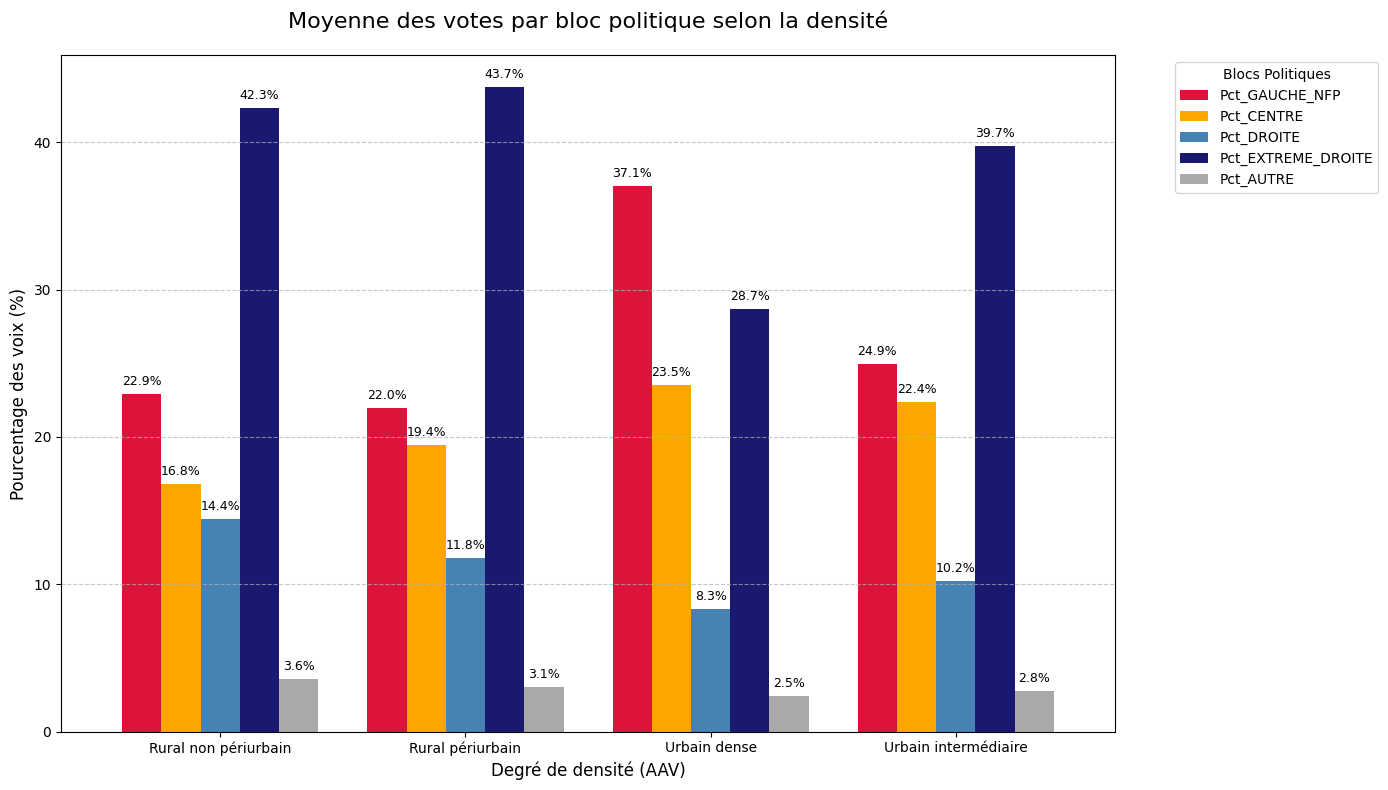

In [169]:
# On prépare les données
colonnes_scores = ['Pct_GAUCHE_NFP', 'Pct_CENTRE', 'Pct_DROITE', 'Pct_EXTREME_DROITE', 'Pct_AUTRE']
df_plot = df_final2.groupby('degre_densite_AAV')[colonnes_scores].mean()

# Création du graphique
ax = df_plot.plot(kind='bar', figsize=(14, 8), width=0.8, color=['crimson', 'orange', 'steelblue', 'midnightblue',
                                                                'darkgray'])

# Personnalisation du style
plt.title('Moyenne des votes par bloc politique selon la densité', fontsize=16, pad=20)
plt.xlabel('Degré de densité (AAV)', fontsize=12)
plt.ylabel('Pourcentage des voix (%)', fontsize=12)
plt.legend(title='Blocs Politiques', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)  # Garde les chiffres de l'abscisse à l'endroit
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajout des étiquettes de score au-dessus des bâtons
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=9)

plt.tight_layout()
plt.show()

Cette différence est visuellement encore plus visible avec ce graphique en barres.

### La régression linéaire du vote à l'extrême droite sur la densité

Enfin, nous avons réalisé une régression linéaire du vote d'extrême droite sur le degré de densité pour voir si ce dernier était une bonne variable prédictive du vote RN.

In [170]:
#régression simple du vote d'extrême droite sur le degré de densité

import statsmodels.api as sm
import statsmodels.formula.api as smf
smf.ols("Pct_EXTREME_DROITE ~ degre_densite_AAV", data = df_final2).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     Pct_EXTREME_DROITE   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     402.7
Date:                Sat, 27 Dec 2025   Prob (F-statistic):          3.62e-257
Time:                        18:09:39   Log-Likelihood:            -1.3693e+05
No. Observations:               34860   AIC:                         2.739e+05
Df Residuals:                   34856   BIC:                         2.739e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=============================================================================================================
                                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                    42.3140      0.097    437.230      0.000      42.124      42.504
degre_densite_AAV[T.Rural périurbain]         1.4005      0.141      9.946      0.000       1.125       1.677
degre_densite_AAV[T.Urbain dense]           -13.6390      0.475    -28.717      0.000     -14.570     -12.708
degre_densite_AAV[T.Urbain intermédiaire]    -2.6033      0.227    -11.461      0.000      -3.048      -2.158
==============================================================================
Omnibus:                     1583.428   Durbin-Watson:                   1.334
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2482.542
Skew:                          -0.405   Prob(JB):                         0.00
Kurtosis:                       4.026   Cond. No.                         8.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Nous constatons déjà un R2 assez faible de 0,033, ce qui signifie que le degré de densité explique 3,3% de la variance du vote. Ce résultat est plutôt logique et indique qu'il y a de nombreux autres facteurs explicatifs du vote à l'extrême droite comme l'âge, la classe sociale... Mais on constate quand même que ce test est très significatif statistiquement avec une p-value de 0. Nous constatons donc bien une corrélation nette entre le vote à l'extrême droite et la densité: si toutes choses égales par ailleurs on prédit un vote à l'extrême droite 1,4% plus élevé dans le rural périurbain, il chute à plus de 13% dans l'urbain dense. 

On peut donc bien conclure sur l'existence d'une corrélation nette entre la densité et le vote, et donc entre l'attractivité des territoires, le nombre d'habitants et le vote, notamment à l'extrême droite.

## Conclusion et perspectives
 
Nous avons pu donc voir une corrélation nette entre la densité et le vote à travers les différnetes statistiques descriptives et la régression du vote d'extrême droite sur la densité. Les explications sur ce lien sont multiples et ont été largement étudiés par la sociologie. Nous ne pouvons par conséquent pas établir une list exhaustive des ouvrages le traitant mais on peut remarquer ces facteurs dans des enquêtes qualitatives comme celle de Félicien Faury dans "Des électeurs ordinaires" par exemple. 
    
Si le territoire joue donc un rôle, beaucoup d'autres facteurs comme la classe sociale et l'âge peuvent aussi expliquer le vote. Nous avons fait le choix de se concentrer uniquement sur la densité et le nombre d'habitants d'abord car fusionner les différentes données sur ces questions nous a paru trop complexe mais surtout parce que l'établissement de liens de causalité précis et de régresssions multiples nous a semblé trop complexe par rapport à nos compétences en économétrie, que nous étudions seulement depuis quelques mois. Nous avons donc quand même cherché à étudier en profondeur ce lien entre densité et les différents votes possibles pour établir une solide corrélation entre les deux